# Adaptadores para modelos de difusión

In [1]:
%pip install -q "diffusers==0.32.2" "transformers==4.46.3" "peft==0.14.0" "accelerate>=0.31" safetensors "qrcode[pil]" opencv-python
%pip uninstall -q -y torchao


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

import gc, warnings, torch, numpy as np, cv2, qrcode
from PIL import Image
import matplotlib.pyplot as plt
from diffusers.utils import load_image, logging as dlog
from transformers.utils import logging as tlog

warnings.filterwarnings("ignore")
dlog.set_verbosity_error()
dlog.disable_progress_bar()
tlog.set_verbosity_error()
tlog.disable_progress_bar()

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32
SD15 = "stable-diffusion-v1-5/stable-diffusion-v1-5"

def show(imgs, titles=None):
    imgs = imgs if isinstance(imgs, (list, tuple)) else [imgs]
    plt.figure(figsize=(4 * len(imgs), 4))
    for i, im in enumerate(imgs):
        plt.subplot(1, len(imgs), i + 1)
        plt.imshow(im)
        plt.axis("off")
        if titles:
            plt.title(titles[i], fontsize=10)
    plt.show()

def flush():
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()

## LoRA

In [3]:
from diffusers import DiffusionPipeline

pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=dtype, variant="fp16", use_safetensors=True,
).to(device)
pipe.set_progress_bar_config(disable=True)

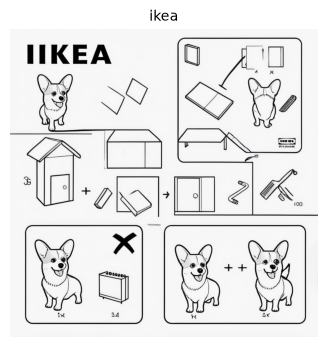

In [4]:
pipe.load_lora_weights("ostris/ikea-instructions-lora-sdxl", weight_name="ikea_instructions_xl_v1_5.safetensors", adapter_name="ikea")
pipe.set_adapters("ikea")

ikea = pipe("a cute corgi, IKEA assembly instructions", num_inference_steps=30).images[0]
show(ikea, ["ikea"])

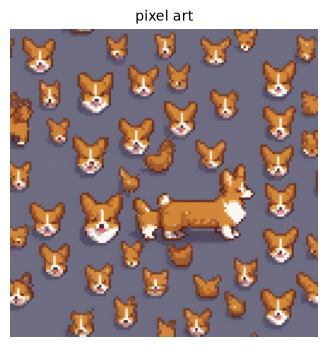

In [5]:
pipe.load_lora_weights("nerijs/pixel-art-xl", weight_name="pixel-art-xl.safetensors", adapter_name="pixel")
pipe.set_adapters("pixel")

pixel = pipe("a cute corgi, pixel art", num_inference_steps=30).images[0]
show(pixel, ["pixel art"])

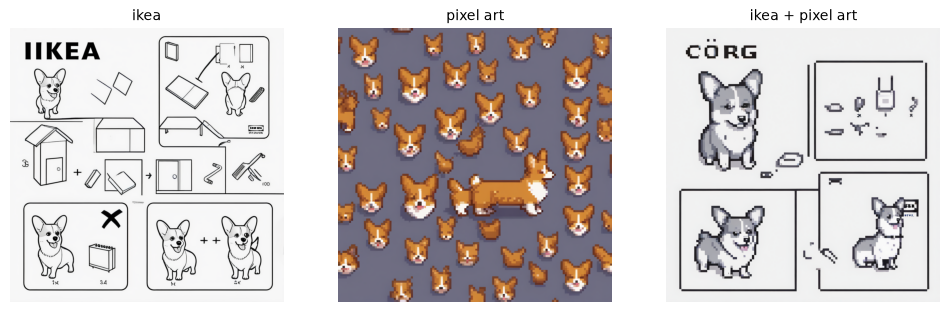

In [6]:
pipe.set_adapters(["ikea", "pixel"], adapter_weights=[1.0, 1.2])

mix = pipe("a cute corgi, IKEA assembly instructions, pixel art", num_inference_steps=30).images[0]
show([ikea, pixel, mix], ["ikea", "pixel art", "ikea + pixel art"])

del pipe
flush()

## ControlNet

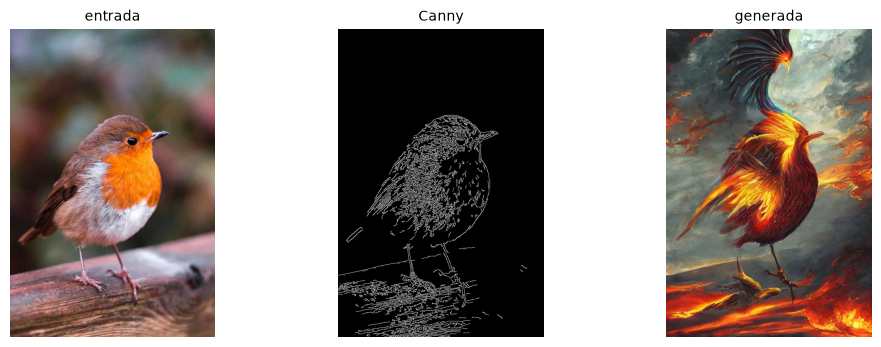

In [7]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel

controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny", torch_dtype=dtype)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    SD15, controlnet=controlnet, torch_dtype=dtype, safety_checker=None,
).to(device)
pipe.set_progress_bar_config(disable=True)

src = load_image("https://huggingface.co/lllyasviel/sd-controlnet-canny/resolve/main/images/bird.png")
edges = cv2.Canny(np.array(src), 100, 200)
canny = Image.fromarray(np.stack([edges] * 3, axis=-1))

out = pipe("a majestic phoenix, fire and embers, fantasy art", image=canny, num_inference_steps=30).images[0]
show([src, canny, out], ["entrada", "Canny", "generada"])

del pipe, controlnet
flush()

### ControlNet para códigos QR

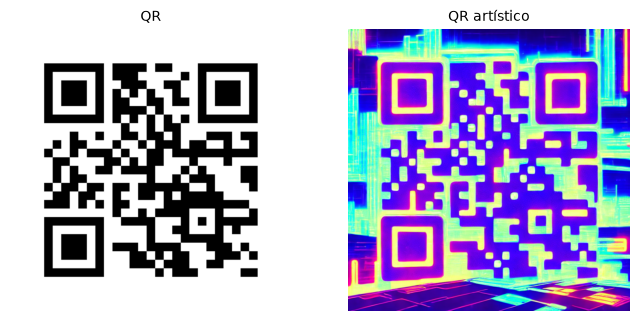

In [8]:
qr = qrcode.QRCode(error_correction=qrcode.constants.ERROR_CORRECT_H, box_size=16, border=4)
qr.add_data("mds.uchile.cl")
qr.make(fit=True)
qr_img = qr.make_image().convert("RGB").resize((768, 768))

controlnet = ControlNetModel.from_pretrained("monster-labs/control_v1p_sd15_qrcode_monster", subfolder="v2", torch_dtype=dtype)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    SD15, controlnet=controlnet, torch_dtype=dtype, safety_checker=None,
).to(device)
pipe.set_progress_bar_config(disable=True)

art = pipe(
    "a futuristic neon cyberpunk city at night, glowing holograms, highly detailed",
    image=qr_img, num_inference_steps=40, guidance_scale=7.5, controlnet_conditioning_scale=2.0,
).images[0]
show([qr_img, art], ["QR", "QR artístico"])

del pipe, controlnet
flush()

## Textual Inversion

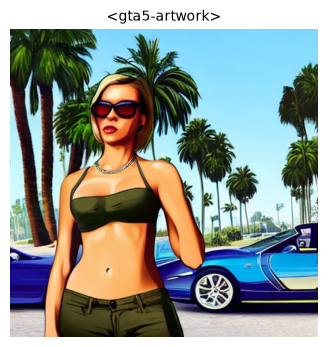

In [9]:
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(SD15, torch_dtype=dtype, safety_checker=None).to(device)
pipe.set_progress_bar_config(disable=True)
pipe.load_textual_inversion("sd-concepts-library/gta5-artwork")

img = pipe(
    "GTA V loading screen art of a woman with sunglasses, palm trees and a sports car, los santos, <gta5-artwork>",
    num_inference_steps=30,
).images[0]
show(img, ["<gta5-artwork>"])

del pipe
flush()

## DreamBooth

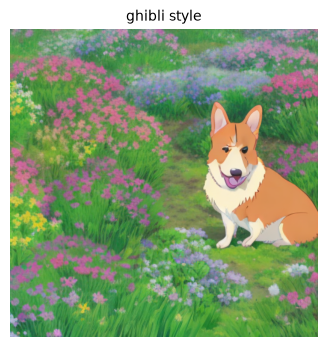

In [10]:
pipe = StableDiffusionPipeline.from_pretrained(
    "nitrosocke/Ghibli-Diffusion", torch_dtype=dtype, safety_checker=None).to(device)
pipe.set_progress_bar_config(disable=True)

img = pipe("a corgi sitting in a flower meadow, ghibli style", num_inference_steps=30).images[0]
show(img, ["ghibli style"])

del pipe
flush()